In [78]:
import numpy as np
import matplotlib.pyplot as plt  
import scipy.stats as sps

In [79]:
lam_plus = 1.2
lam_minus = 1.5
Q_ASK = 10
Q_BID = 10
LAM_PLUS = lam_plus
LAM_MINUS = lam_minus
mu = lam_plus - lam_minus
sigma2 = lam_plus + lam_minus
sigma = np.sqrt(sigma2)
MU = mu
SIGMA2 = sigma2
SIGMA = sigma
mu_plus = 1.0
mu_minus = 1.1
alpha = 0.3
beta = 0.6
MU_PLUS = mu_plus
MU_MINUS = mu_minus
ALPHA = alpha
BETA = beta
N = 1000


## Q1.2.3.0- Simulation des deux files:

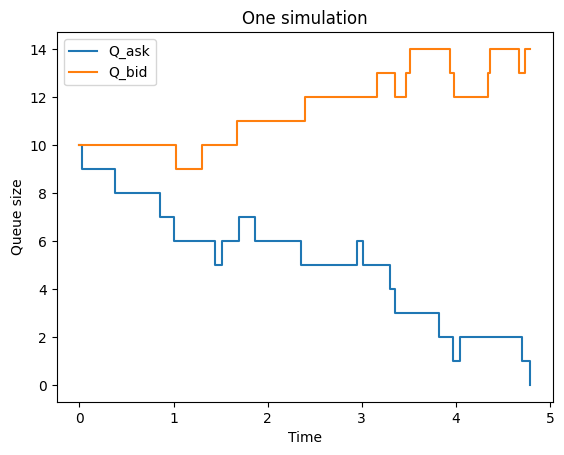

Temps final : 4.792951238317587
ASK vide en premier : True


In [80]:
def Files(lam_plus, lam_minus, Q_ask, Q_bid):
    t = 0.0
    times = [t]
    ask_vals = [Q_ask]
    bid_vals = [Q_bid]

    total_rate = 2 * (lam_plus + lam_minus)

    while Q_ask > 0 and Q_bid > 0:
        t += np.random.exponential(1 / total_rate)
        U = np.random.uniform(0, total_rate)

        if U < lam_plus:
            Q_ask += 1
        elif U < lam_plus + lam_minus:
            Q_ask -= 1
        elif U < 2 * lam_plus + lam_minus:
            Q_bid += 1
        else:
            Q_bid -= 1

        times.append(t)
        ask_vals.append(Q_ask)
        bid_vals.append(Q_bid)

    ask_empty = (Q_ask == 0)
    return times, ask_vals, bid_vals, t, ask_empty


times, ask_vals, bid_vals, T, ask_empty = Files(lam_plus, lam_minus, Q_ASK, Q_BID)

plt.figure()
plt.step(times, ask_vals, where='post', label='Q_ask')
plt.step(times, bid_vals, where='post', label='Q_bid')
plt.xlabel("Time")
plt.ylabel("Queue size")
plt.title("One simulation")
plt.legend()
plt.show()

print("Temps final :", T)
print("ASK vide en premier :", ask_empty)


Question 1.2.3:  On simule deux files indépendantes, avec des arrivées à taux constant et des départs à taux constant qui vaut 1.2 pour les arrivées et 1.5 pour les départs. On regarde le premier temps d'atteinte de 0 peu importe la file, et on garde en mémoire les différentes valeurs qu'ont pris les files bid et ask au cours des évenements, le temps d'occurence des différents évènements, et le temps d'atteinte de 0 pour une des files. 

In [81]:
def deux_files(init, lam_plus, lam_minus):
    t = 0
    A = init
    V = init
    # Tableaux pour stocker les données de temps, ventes et achats
    temps = [t]
    ventes = [A]
    achats = [V]

    # Simulation jusqu'à ce que l'une des files atteigne 0
    while A > 0 and V > 0:
        # Calcul du temps jusqu'au prochain événement
        t += np.random.exponential(1 / (2 * (lam_plus + lam_minus)))
        
        # Détermination de l'événement (vente ou achat)
        if np.random.rand() < 0.5:

            # Si c'est une vente, on décide si c'est une augmentation ou diminution de la file de vente
            if np.random.rand() < lam_plus / (lam_plus + lam_minus):
                A += 1
            else:
                A -= 1
        else:
            # Si c'est un achat, on décide si c'est une augmentation ou diminution de la file d'achat
            if np.random.rand() < lam_plus / (lam_plus + lam_minus):
                V += 1
            else:
                V -= 1

        # Stockage des données après chaque événement
        temps.append(t)
        ventes.append(A)
        achats.append(V)

    return t, temps, ventes, achats

On fait de même mais en ne regardant qu'une seule file cette fois ci, et en gardant en mémoire le temps l'occurence de chaque incrémentation, ou diminution, et l'évolution de la file à chaque evenement, et finalemenet le temps d'atteinte de 0. 

In [82]:
def une_file(init, lam_plus, lam_minus):
    t = 0.0
    q = init
    temps = [t]
    valeurs = [q]

    while q > 0:
        t += np.random.exponential(1 / (lam_plus + lam_minus))
        if np.random.rand() < lam_plus / (lam_plus + lam_minus):
            q += 1
        else:
            q -= 1
        temps.append(t)
        valeurs.append(q)

    return temps, valeurs, t

   

1.2.3.2: On souhaite simuler la distribution des temps d'atteinte de zéro par l'une des files (ask) en la superposant à une simulation brownienne discrétisée:

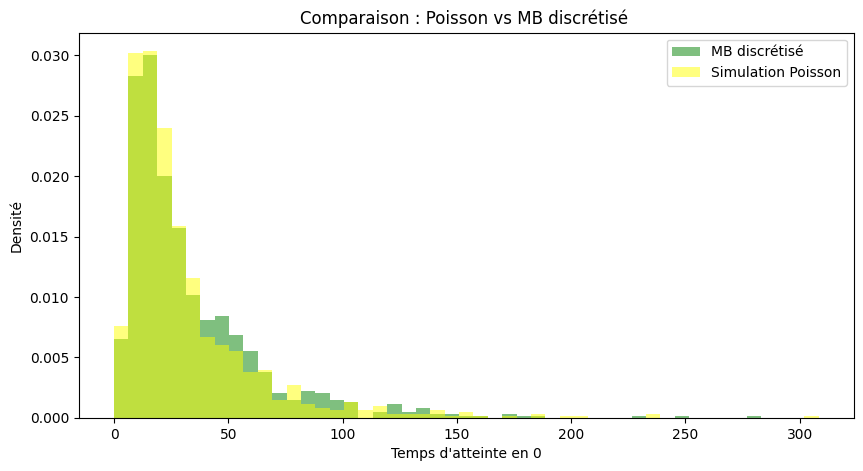

In [83]:
mu=LAM_PLUS-LAM_MINUS
sigma=np.sqrt(LAM_PLUS+LAM_MINUS)
def deux_files(init, lam_plus, lam_minus):
    t = 0
    A = init
    V = init
    temps = [t]
    ventes = [A]
    achats = [V]

    while A > 0 and V > 0:
        t += np.random.exponential(1 / (2 * (lam_plus + lam_minus)))
        if np.random.rand() < 0.5:
            if np.random.rand() < lam_plus / (lam_plus + lam_minus):
                A += 1
            else:
                A -= 1
        else:
            if np.random.rand() < lam_plus / (lam_plus + lam_minus):
                V += 1
            else:
                V -= 1

        temps.append(t)
        ventes.append(A)
        achats.append(V)

    return t, temps, ventes, achats


def une_file(init, lam_plus, lam_minus):
    t = 0.0
    q = init
    temps = [t]
    valeurs = [q]

    while q > 0:
        t += np.random.exponential(1 / (lam_plus + lam_minus))
        if np.random.rand() < lam_plus / (lam_plus + lam_minus):
            q += 1
        else:
            q -= 1
        temps.append(t)
        valeurs.append(q)

    return temps, valeurs, t


def moyenne_temps_atteinte(N, init, lam_plus, lam_minus):
    tt = []
    for _ in range(N):
        _, _, tau = une_file(init, lam_plus, lam_minus)
        tt.append(tau)
    tt = np.array(tt)
    m = np.mean(tt)
    s = np.std(tt, ddof=1)
    ic = 1.96 * s / np.sqrt(N)
    return m, m - ic, m + ic


def brownien(init, mu, sigma, dt=0.01, tmax=1000):
    t = 0
    x = init
    temps = [t]
    valeurs = [x]

    while x > 0 and t < tmax:
        x = x + mu * dt + sigma * np.sqrt(dt) * np.random.randn()
        t += dt
        temps.append(t)
        valeurs.append(x)

    return temps, valeurs
# Simulation
taus_ask=[une_file(Q_ASK,LAM_PLUS,LAM_MINUS)[2] for _ in range(N)]
taus_bm_discret = [brownien(Q_ASK, mu, sigma)[0][-1] for _ in range(N)]

# Comparaison
bins = np.linspace(0, max(max(taus_ask), max(taus_bm_discret)), 50)

plt.figure(figsize=(10, 5))
plt.hist(taus_bm_discret, bins=bins, density=True, alpha=0.5, color='green',   label='MB discrétisé')
plt.hist(taus_ask,        bins=bins, density=True, alpha=0.5, color='yellow', label='Simulation Poisson')
plt.xlabel("Temps d'atteinte en 0")
plt.ylabel("Densité")
plt.title("Comparaison : Poisson vs MB discrétisé ")
plt.legend()
plt.show()


Puis à la distribution théorique brownienne :

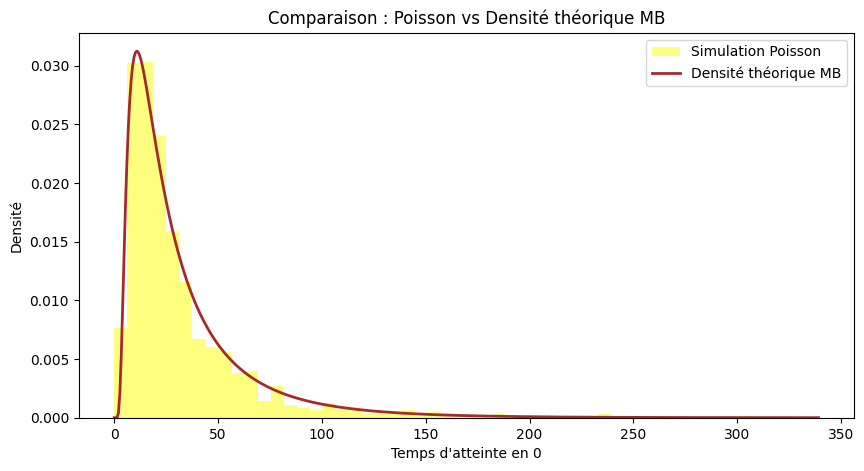

In [84]:
t_grid = np.linspace(0.1, max(taus_ask)*1.1, 500)
pdf    = (Q_ASK / (sigma * np.sqrt(2*np.pi*t_grid**3))) \
         * np.exp(-(Q_ASK + mu*t_grid)**2 / (2*sigma**2*t_grid))
        
plt.figure(figsize=(10, 5))
plt.hist(taus_ask,bins=bins, density=True, alpha=0.5, color='yellow', label='Simulation Poisson')
plt.plot(t_grid, pdf, color='brown', lw=2, label='Densité théorique MB')

plt.xlabel("Temps d'atteinte en 0")
plt.ylabel("Densité")
plt.title("Comparaison : Poisson vs Densité théorique MB")
plt.legend()
plt.show()


1.2.3.3: On veut simuler le temps moyen d’atteinte de zéro d’une des file d’attente et calculer un intervalle
de confiance.
On simule alors N trajectoires et one calcule la moyenne et de l'intervalle de confiance à 95% pour le temps d'atteinte de 0

In [85]:
def moyenne_temps_atteinte(N, init, lam_plus, lam_minus):

    tt = []
    # Boucle pour simuler N fois et stocker les temps d'atteinte de 0
    for _ in range(N):
        # On simule une file et garder le temps d'atteinte de 0
        _, _, tau = une_file(init, lam_plus, lam_minus)
        tt.append(tau)
    tt = np.array(tt)

    # Calcul de la moyenne, de l'écart-type et de l'intervalle de confiance à 95%
    m = np.mean(tt)
    s = np.std(tt, ddof=1)
    ic = 1.96 * s / np.sqrt(N)
    # On retourne la moyenne et l'intervalle de confiance
    return m, m - ic, m + ic

On affiche de la valeur moyenne et de l'intervalle de confiance sur N = 1000 essais.

In [86]:
N = 1000
m, m_moins, m_plus = moyenne_temps_atteinte(N, init=Q_ASK, lam_plus=lam_plus, lam_minus=lam_minus)
print(f"Le temps moyen d'atteinte de 0 est: {m:.2f}. L'intervalle de confiance a 95% est [{m_moins:.2f}, {m_plus:.2f}]")


Le temps moyen d'atteinte de 0 est: 34.87. L'intervalle de confiance a 95% est [32.78, 36.97]


1.2.3.4 : On simula la moyenne de premier temps d'atteinte en 0 en fonction des tailles initiales de chaque file, pour ce faire on fait varier les tailles initiales des files entre 1 et 20 :

In [88]:
N4 = 500
Q_range=np.arange(1,21)
moyennes=np.zeros((len(Q_range),len(Q_range)))

for i, Q1 in enumerate(Q_range):
    for j, Q2 in enumerate(Q_range):
       taus=[]
       for _ in range(N4):
          times, ask_vals, bid_vals, T, ask_empty = Files(LAM_PLUS, LAM_MINUS, Q1, Q2)
          taus.append(T)
          moyennes[i,j]=np.mean(taus)
          

plt.imshow(moyennes, origin='lower',
           extent=[Q_range[0], Q_range[-1], Q_range[0], Q_range[-1]])
plt.colorbar(label="E[min(tau₁, tau₋₁)]")
plt.xlabel("Q₋₁(0)")
plt.ylabel("Q₁(0)")
plt.title("Temps moyen d'atteinte de 0")
plt.show()       



KeyboardInterrupt: 

1.2.3.5:  On simule la probabilité que 𝑄1 (0) touche zéro avant 𝑄−1(0) en fonction de 𝑄1 (0) et 𝑄−1(0). (Ici, on prend Q1(0)= Q-1(0), SPG)
On simule N fois les deux files et on compte combien de fois la file de vente atteint 0 avant la file d'achat

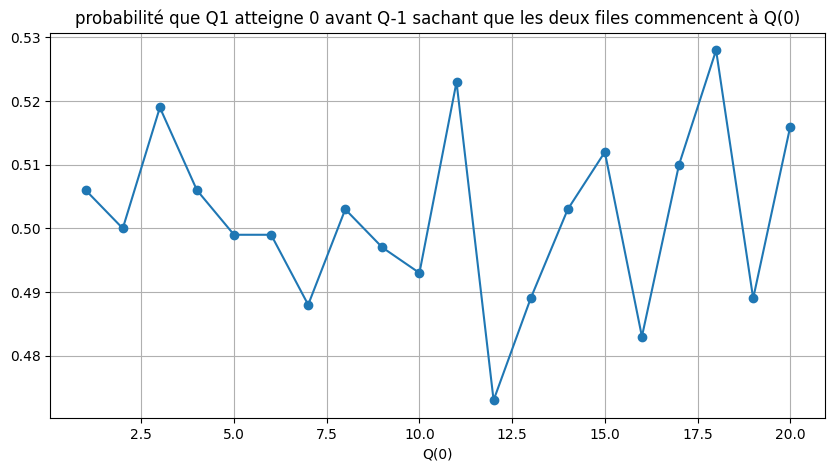

In [89]:
def prob_Q1(N, init, lam_plus, lam_moins):
    inc = 0
    for _ in range(N):
        _, _, ventes, achats = deux_files(init, lam_plus, lam_moins)

        # On trouve l'index où l'une des files atteint 0
        for i in range(1, len(ventes)):
            if ventes[i] == 0:
                inc += 1
                break
            elif achats[i] == 0:
                break
    
    proba = inc / N
    return proba

plt.figure(figsize=(10, 5))
Q_range = np.arange(1, 21)
probas = [prob_Q1(N, Q, LAM_PLUS, LAM_MINUS) for Q in Q_range]
plt.plot(Q_range, probas, marker='o')
plt.xlabel("Q(0)")
plt.title("probabilité que Q1 atteigne 0 avant Q-1 sachant que les deux files commencent à Q(0)")
plt.grid()
plt.show()

Question 1.2.4: Processus de Hawkes 
1.2.4.1: Simuler une file d’attente de Hawkes et approcher son intensité stationnaire 𝜆−


1.2.4.2: Estimer la distribution des temps d’atteinte de zero par cette file d’attente.
Simulation pour estimer la probabilité que la file de vente atteigne 0 avant la file d'achat


In [90]:
def hawkes_une_file(init, mu_plus, mu_minus, alpha, beta):
    t = 0.0
    q = int(init)
    z_plus = 0.0
    z_minus = 0.0

    temps = [t]
    tailles = [q]
    intensites_moins = []

    while q > 0:
        lam_plus_h = mu_plus
        lam_minus_h = max(1e-12, mu_minus - alpha * z_plus + alpha * z_minus)
        total = lam_plus_h + lam_minus_h

        dt = np.random.exponential(1 / total)
        noyau = np.exp(-beta * dt)
        z_plus *= noyau
        z_minus *= noyau
        t += dt

        if np.random.random() < lam_plus_h / total:
            q += 1
            z_plus += 1
        else:
            q -= 1
            z_minus += 1

        temps.append(t)
        tailles.append(q)
        intensites_moins.append(lam_minus_h)

    return t, temps, tailles, intensites_moins


1.2.4.3
On commence par estimer la distribution des temps d’atteinte de zero pour les deux files d’attente couplées. 

In [91]:
def temps_atteinte_zero_deux_files(init_achat, init_vente, mu_plus, mu_minus, alpha, beta):
    t = 0.0
    achat = int(init_achat)
    vente = int(init_vente)

    z_aug_achat = 0.0
    z_dim_achat = 0.0
    z_aug_vente = 0.0
    z_dim_vente = 0.0

    while achat > 0 and vente > 0:
        lam_achat = max(0, mu_minus - alpha * (z_aug_achat + z_dim_vente) + alpha * (z_dim_achat + z_aug_vente))
        lam_vente = max(0, mu_minus - alpha * (z_aug_vente + z_dim_achat) + alpha * (z_dim_vente + z_aug_achat))
        total = 2 * mu_plus + lam_achat + lam_vente

        dt = np.random.exponential(1 / total)
        noyau = np.exp(-beta * dt)
        z_aug_achat *= noyau
        z_dim_achat *= noyau
        z_aug_vente *= noyau
        z_dim_vente *= noyau
        t += dt

        u = np.random.random() * total
        if u < mu_plus:
            achat += 1
            z_aug_achat += 1
        elif u < 2 * mu_plus:
            vente += 1
            z_aug_vente += 1
        elif u < 2 * mu_plus + lam_achat:
            achat -= 1
            z_dim_achat += 1
        else:
            vente -= 1
            z_dim_vente += 1

    if achat == 0:
        side = -1
    else:
        side = +1
    return t, achat, vente, side


1.2.4.4 Simulation de plusieurs trajectoires pour estimer la distribution des temps d'atteinte de 0 et affichage de l'historiogramme

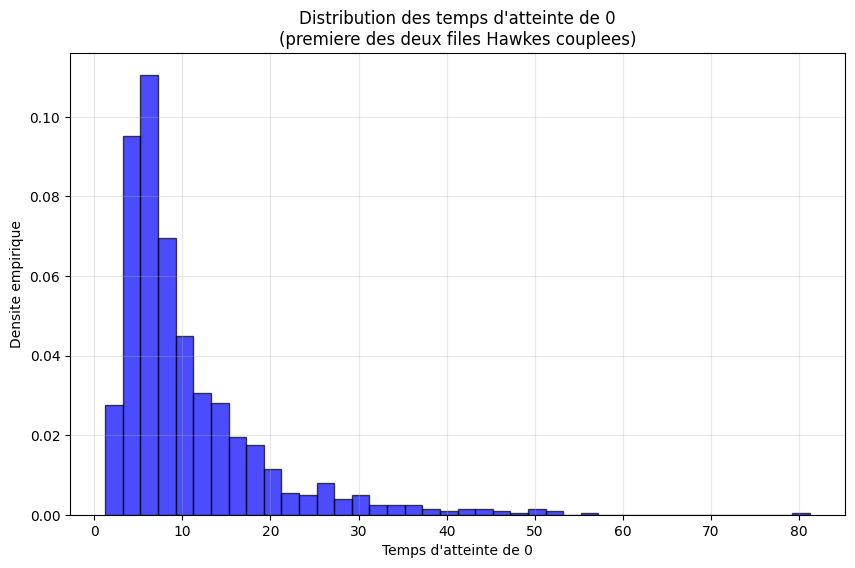

In [92]:
n = 1000
T = np.empty(n)
for i in range(n):
    T[i] = temps_atteinte_zero_deux_files(Q_ASK, Q_BID, mu_plus, mu_minus, alpha, beta)[0]

plt.figure(figsize=(10, 6))
plt.hist(T, bins=40, density=True, alpha=0.7, color='blue', edgecolor='black')
plt.xlabel("Temps d'atteinte de 0")
plt.ylabel("Densite empirique")
plt.title("Distribution des temps d'atteinte de 0\n(premiere des deux files Hawkes couplees)")
plt.grid(alpha=0.3)
plt.show()


1.2.4.5

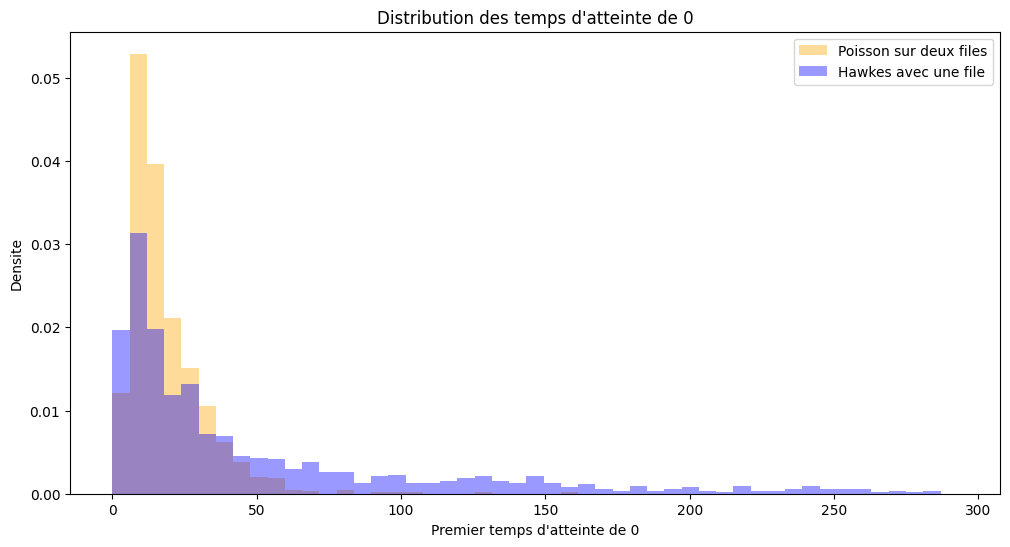

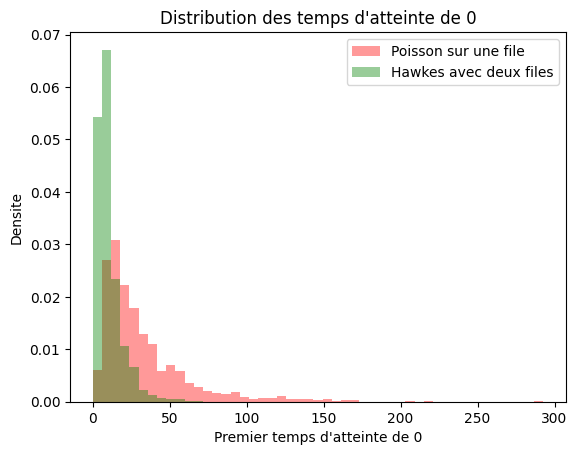

In [93]:
N_sim = 1000

tau_poisson_single = [une_file(Q_ASK, lam_plus, lam_minus)[2] for _ in range(N_sim)]
tau_poisson_two = [deux_files(Q_ASK, lam_plus, lam_minus)[0] for _ in range(N_sim)]
tau_hawkes_single = [hawkes_une_file(Q_ASK, mu_plus, mu_minus, alpha, beta)[0] for _ in range(N_sim)]
tau_hawkes_two = [temps_atteinte_zero_deux_files(Q_ASK, Q_BID, mu_plus, mu_minus, alpha, beta)[0]
                  for _ in range(N_sim)]

bins_comp = np.linspace(0, max(max(tau_poisson_single), max(tau_hawkes_two)), 50)


plt.figure(figsize=(12, 6))
plt.hist(tau_poisson_two, bins=bins_comp, density=True, alpha=0.4, color='orange', label='Poisson sur deux files')
plt.hist(tau_hawkes_single, bins=bins_comp, density=True, alpha=0.4, color='blue', label='Hawkes avec une file')
plt.xlabel("Premier temps d'atteinte de 0")
plt.ylabel("Densite")
plt.legend()
plt.title("Distribution des temps d'atteinte de 0")
plt.show()

plt.figure()
plt.hist(tau_poisson_single, bins=bins_comp, density=True, alpha=0.4, color='red', label='Poisson sur une file')
plt.hist(tau_hawkes_two, bins=bins_comp, density=True, alpha=0.4, color='green', label='Hawkes avec deux files')
plt.xlabel("Premier temps d'atteinte de 0")
plt.ylabel("Densite")
plt.legend()
plt.title("Distribution des temps d'atteinte de 0")
plt.show()


1.2.5 : Deuxième limite 

1.2.5.1 : On va simuler la distribution de la deuxième limite ask conditionnement au fait que la première ait touché 0 :

In [94]:
Q2_0 = 10
M = 500
R = 3000

In [95]:
def simule_N2_constant(T, q2_0=Q2_0):
    t = 0.0
    q2 = int(q2_0)
    taux_total = lam_plus + lam_minus

    while t < T:
        dt = np.random.exponential(1 / taux_total)

        if t + dt > T:
            break

        t += dt

        if np.random.random() < lam_plus / taux_total:
            q2 += 1
        else:
            q2 = max(0, q2 - 1)

    return q2

In [96]:
def temps_conditionnels(cote, M):
    taus = []

    while len(taus) < M:
        tau, achat, vente, side = temps_atteinte_zero_deux_files(
            Q_BID, Q_ASK, mu_plus, mu_minus, alpha, beta
        )

        if side == cote:
            taus.append(tau)

    return taus

In [97]:
def simule_1251(cote, M=500, R=3000):
    taus = temps_conditionnels(cote, M)
    valeurs_q2 = []

    for _ in range(R):
        tau = np.random.choice(taus)
        valeurs_q2.append(simule_N2_constant(tau, Q2_0))

    return np.array(valeurs_q2), taus

In [98]:
def plot_1251(cote, titre, couleur, M=500, R=3000):  
    
    valeurs_q2, taus = simule_1251(cote, M, R)

    bins = np.arange(0, np.max(valeurs_q2) + 2) - 0.5

    plt.figure(figsize=(10, 5))
    plt.hist( valeurs_q2,bins=bins, density=True, color=couleur, alpha=0.5, rwidth=0.8 )


    plt.xlabel("N+2 au temps tau")
    plt.ylabel("Densité empirique")
    plt.title(titre)
    plt.legend()
    plt.tight_layout()
    plt.show()

    print("Nombre de temps conditionnels :", len(taus))
    print("Moyenne de N+2_tau :", np.mean(valeurs_q2))
    print("Variance de N+2_tau :", np.var(valeurs_q2))

    return valeurs_q2, taus

/var/folders/tm/qx0lly2j59v8tvyfdntzhq740000gn/T/ipykernel_40635/2849296176.py:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


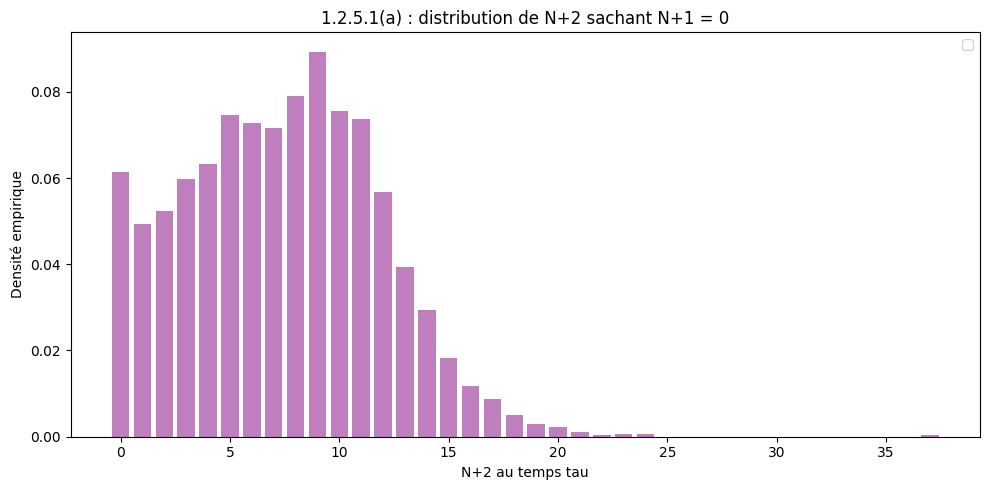

Nombre de temps conditionnels : 500
Moyenne de N+2_tau : 7.377
Variance de N+2_tau : 19.760204333333334


In [ ]:
q2_1251_a, tau_1251_a = plot_1251(
    +1,
    "Distribution de N+2 sachant N+1 = 0",
    "purple",
    M=500,
    R=3000
)

/var/folders/tm/qx0lly2j59v8tvyfdntzhq740000gn/T/ipykernel_40635/2849296176.py:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


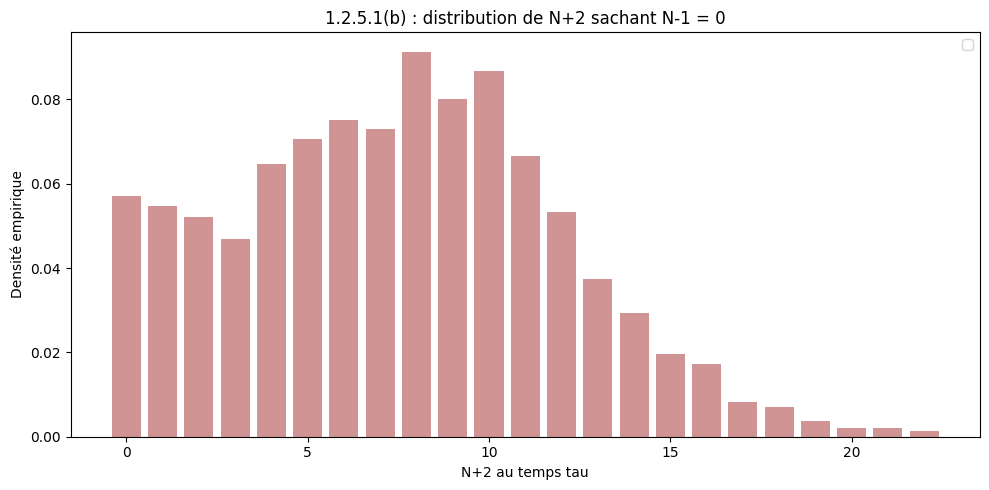

Nombre de temps conditionnels : 500
Moyenne de N+2_tau : 7.480333333333333
Variance de N+2_tau : 19.795613222222222


In [ ]:
q2_1251_b, tau_1251_b = plot_1251(
    -1,
    "Distribution de N+2 sachant N-1 = 0",
    "brown",
    M=500,
    R=3000
)

1.2.5.2 : On refait la question precedente, mais avec une croissance de la deuxieme limite.

Ici, la memoire `x` augmente apres les departs de `N+1`, decroit exponentiellement avec le parametre `b`, puis ajoute `a*x` a l'intensite d'arrivee de `N+2`. Pour garder assez de trajectoires conditionnelles, on utilise un splitting  quand la premiere limite  arrive pres de zero.


In [ ]:
def temps_atteinte_zero_deux_files2(etat, a, mode="zero", cote=+1, seuil=2):
    t, q_plus, q_minus, q2, z_plus, z_minus, x2 = etat

    while q_plus > 0 and q_minus > 0:
        if mode == "seuil":
            q_surveillee = q_plus if cote == +1 else q_minus
            if q_surveillee <= seuil:
                return (t, q_plus, q_minus, q2, z_plus, z_minus, x2), 0

        # Dynamique Hawkes des premières limites.
        lam_dim_plus = max(1e-12, lam_minus - alpha * z_plus + alpha * z_minus)

    
        lam_dim_minus = max(1e-12, lam_minus - alpha * z_minus + alpha * z_plus)

        # Deuxième limite +2 :
        # x2 = somme exp(-b(t-s_j)) sur les départs de N^{+1}
        # donc a*x2 = D(t)
        lam_ajout_q2 = max(1e-12, lam_plus + a * x2)
        lam_dim_q2 = max(1e-12, lam_minus)

        total = 2 * lam_plus + lam_dim_plus + lam_dim_minus + lam_ajout_q2 + lam_dim_q2

        dt = np.random.exponential(1 / total)
        t += dt

        z_plus *= np.exp(-beta * dt)
        z_minus *= np.exp(-beta * dt)
        x2 *= np.exp(-b * dt)

        u = np.random.random() * total

        if u < lam_plus:
            q_plus += 1
            z_plus += 1

        elif u < 2 * lam_plus:
            q_minus += 1
            z_minus += 1

        elif u < 2 * lam_plus + lam_dim_plus:
            q_plus -= 1
            z_plus -= 1
            x2 += 1

        elif u < 2 * lam_plus + lam_dim_plus + lam_dim_minus:
            q_minus -= 1
            z_minus -= 1

        elif u < 2 * lam_plus + lam_dim_plus + lam_dim_minus + lam_ajout_q2:
            q2 += 1

        else:
            q2 = max(0, q2 - 1)

    side = +1 if q_plus <= 0 else -1
    return (t, q_plus, q_minus, q2, z_plus, z_minus, x2), side

In [128]:
def simulation_splitting(a, cote, q0, q2_0, seuil=2, n_reprises=12):
    etat0 = (0.0, int(q0), int(q0), int(q2_0), 0.0, 0.0, 0.0)

    etat, side = temps_atteinte_zero_deux_files2(etat0, a, "seuil", cote, seuil)

    if side != 0:
        if side == cote:
            return np.array([etat[3]])
        return np.array([])

    valeurs = []

    for _ in range(n_reprises):
        etat_fin, side_fin = temps_atteinte_zero_deux_files2(etat, a, "zero", cote, seuil)

        if side_fin == cote:
            valeurs.append(etat_fin[3])

    return valeurs

In [131]:
def plot_splitting(a_values, cote, titre, N=800, q0=10, q2_0=10, seuil=2, n_reprises=12, color_map=plt.cm.plasma):
    resultats = {}

    for a in a_values:
        valeurs = []

        for _ in range(N):
            valeurs_a = simulation_splitting(a, cote, q0, q2_0, seuil, n_reprises)
            valeurs.extend(valeurs_a)

        resultats[a] = np.array(valeurs)

    toutes_valeurs = [v for v in resultats.values() if len(v) > 0]

    if len(toutes_valeurs) == 0:
        print("Aucune trajectoire retenue. Augmenter N ou n_reprises.")
        return resultats

    max_val = max(int(np.max(v)) for v in toutes_valeurs)
    bins = np.arange(0, max_val + 2) - 0.5

    plt.figure(figsize=(11, 5))
    colors = color_map(np.linspace(0.15, 0.9, len(a_values)))

    for a, color in zip(a_values, colors):
        valeurs = resultats[a]

        if len(valeurs) > 0:
            plt.hist(
                valeurs,
                bins=bins,
                density=True,
                alpha=0.35,
                color=color,
                rwidth=0.8,
                label=f"a={a}, moy={np.mean(valeurs):.1f}, n={len(valeurs)}"
            )

    plt.xlabel("N+2 au temps tau")
    plt.ylabel("Densité empirique")
    plt.title(titre)
    plt.legend(fontsize=9)
    plt.tight_layout()
    plt.show()

    return resultats

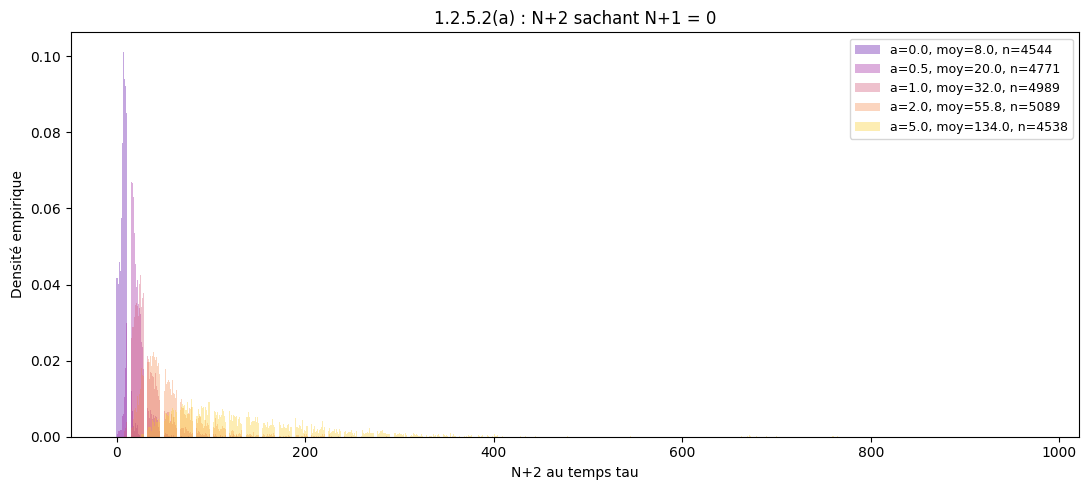

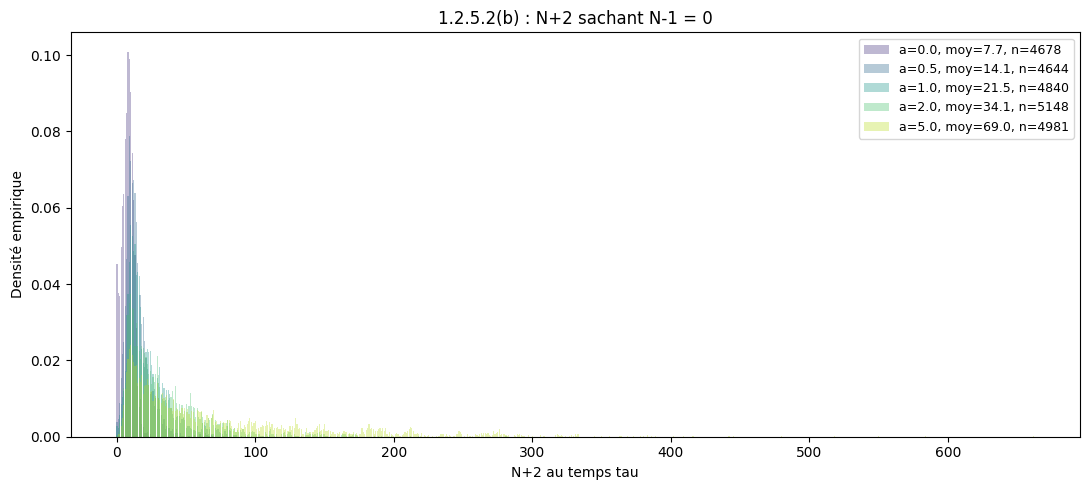

In [130]:
a_values = [0.0, 0.5, 1.0, 2.0, 5.0]
b = 0.5

resultats_1252_a = plot_splitting(
    a_values,
    +1,
    "1.2.5.2(a) : N+2 sachant N+1 = 0",
    N=800,
    q0=Q_ASK,
    q2_0=Q2_0,
    seuil=2,
    n_reprises=12,
    color_map=plt.cm.plasma
)

resultats_1252_b = plot_splitting(
    a_values,
    -1,
    "1.2.5.2(b) : N+2 sachant N-1 = 0",
    N=800,
    q0=Q_ASK,
    q2_0=Q2_0,
    seuil=2,
    n_reprises=12,
    color_map=plt.cm.viridis
)